In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [ ]:
df = pd.read_csv('retail.csv')

In [ ]:
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  01-12-2010 08:26       2.55     17850.0  United Kingdom  
1  01-12-2010 08:26       3.39     17850.0  United Kingdom  
2  01-12-2010 08:26       2.75     17850.0  United Kingdom  
3  01-12-2010 08:26       3.39     17850.0  United Kingdom  
4  01-12-2010 08:26       3.39     17850.0  United Kingdom  


In [ ]:
df = df.dropna()

In [ ]:
df = df[['Quantity', 'UnitPrice', 'Country']]

In [ ]:
encoder=LabelEncoder()
df['Country']=encoder.fit_transform(df['Country'])

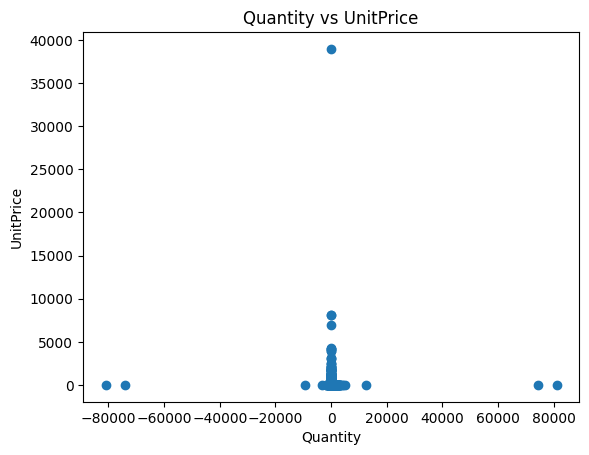

In [ ]:
plt.Figure(figsize=(8,5))
plt.scatter(df['Quantity'], df['UnitPrice'])
plt.xlabel('Quantity')
plt.ylabel('UnitPrice')
plt.title('Quantity vs UnitPrice')
plt.show()

In [ ]:
x=df[['Quantity', 'UnitPrice']]
y=df['Country']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("LogisticRegression")
log_model = LogisticRegression()
log_model.fit(x_train, y_train)
log_predictions = log_model.predict(x_test)
log_accuracy = accuracy_score(y_test, log_predictions)
print("Accuracy:", log_accuracy)
print("Confusion Matrix:")
print(confusion_matrix(y_test, log_predictions))

print("DecisionTreeClassifier")
tree_model = DecisionTreeClassifier()
tree_model.fit(x_train, y_train)
tree_predictions = tree_model.predict(x_test)
tree_accuracy = accuracy_score(y_test, tree_predictions)
print("Accuracy:", tree_accuracy)
print("Confusion Matrix:")
print(confusion_matrix(y_test, tree_predictions))

print("KNeighborsClassifier")
knn_model = KNeighborsClassifier()
knn_model.fit(x_train, y_train)
knn_predictions = knn_model.predict(x_test)
knn_accuracy = accuracy_score(y_test, knn_predictions)
print("Accuracy:", knn_accuracy)
print("Confusion Matrix:")
print(confusion_matrix(y_test, knn_predictions))


LogisticRegression


c:\Users\Lenovo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.8897328122311531
Confusion Matrix:
[[    0     0     0 ...     0   229     0]
 [    0     0     0 ...     0    78     0]
 [    0     0     0 ...     0     5     0]
 ...
 [    0     0     0 ...     0    13     0]
 [    0     0     0 ...     0 72394     0]
 [    0     0     0 ...     0    43     0]]
DecisionTreeClassifier
Accuracy: 0.8903104490819261
Confusion Matrix:
[[   13     0     0 ...     0   197     0]
 [    0     0     0 ...     0    75     0]
 [    0     0     0 ...     0     5     0]
 ...
 [    0     0     0 ...     0    13     0]
 [   21     0     0 ...     1 72219     0]
 [    0     0     0 ...     0    43     0]]
KNeighborsClassifier
Accuracy: 0.8851977484452965
Confusion Matrix:
[[   18     0     0 ...     0   180     0]
 [    0     1     0 ...     0    75     0]
 [    0     0     0 ...     0     5     0]
 ...
 [    0     0     0 ...     0    12     0]
 [   36     1     0 ...     0 71772     0]
 [    0     0     0 ...     0    43     0]]


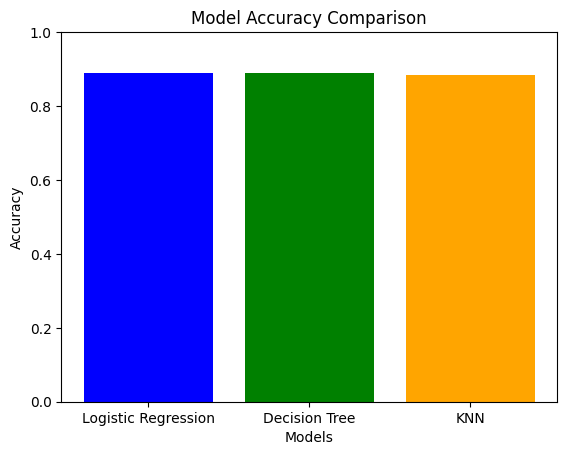

In [ ]:
#visualization the accuracy of the models
models = ['Logistic Regression', 'Decision Tree', 'KNN']
accuracies = [log_accuracy, tree_accuracy, knn_accuracy]
plt.bar(models, accuracies, color=['blue', 'green', 'orange'])
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)
plt.show()

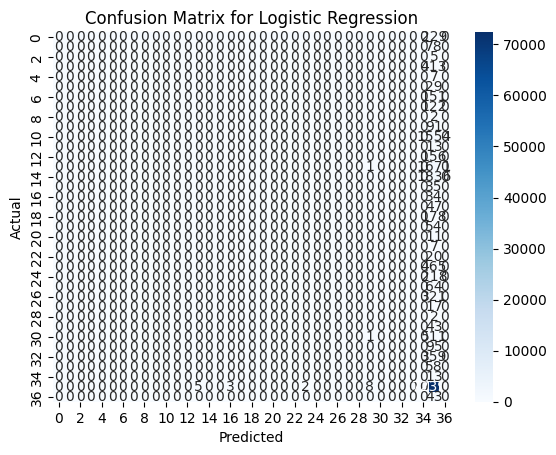

In [ ]:
import seaborn as sns
sns.heatmap(confusion_matrix(y_test, log_predictions), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()
